In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo general de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('./Data/Data_set_02.csv')
print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 8000 filas × 26 columnas


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


---
## 2. Resumen general del dataset

In [3]:
# Tabla de estadísticas descriptivas (solo columnas numéricas clave)
cols_key = [
    'age', 'study_hours_per_day', 'ai_usage_time_minutes',
    'ai_dependency_score', 'ai_generated_content_percentage',
    'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
    'final_score', 'sleep_hours', 'social_media_hours'
]
df[cols_key].describe().round(2)

,age,study_hours_per_day,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,final_score,sleep_hours,social_media_hours
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,18.97,3.29,88.99,5.52,50.06,59.36,5.47,59.50,56.81,6.47,3.01
std,3.15,1.58,52.18,2.88,29.44,34.87,2.87,23.16,13.46,1.44,1.74
min,14.00,0.50,0.00,1.00,0.00,0.00,1.00,20.00,12.70,4.00,0.00
25%,16.00,1.90,43.00,3.00,25.00,29.00,3.00,39.75,47.30,5.20,1.50
50%,19.00,3.30,89.00,6.00,50.00,59.00,6.00,59.00,56.90,6.40,3.00
75%,22.00,4.60,134.00,8.00,76.00,90.00,8.00,80.00,66.20,7.70,4.50
max,24.00,6.00,179.00,10.00,100.00,119.00,10.00,99.00,95.80,9.00,6.00


In [4]:
# Valores nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print('Columnas con valores nulos:')
print(nulls.to_string())
print('\nNota: ai_tools_used y ai_usage_purpose tienen ~1.350 nulos.')
print('Corresponden a estudiantes que no usan IA (uses_ai = 0).')

Columnas con valores nulos:
ai_tools_used       1362
ai_usage_purpose    1346

Nota: ai_tools_used y ai_usage_purpose tienen ~1.350 nulos.
Corresponden a estudiantes que no usan IA (uses_ai = 0).


---
## 3. Perfil del estudiante — variables categóricas

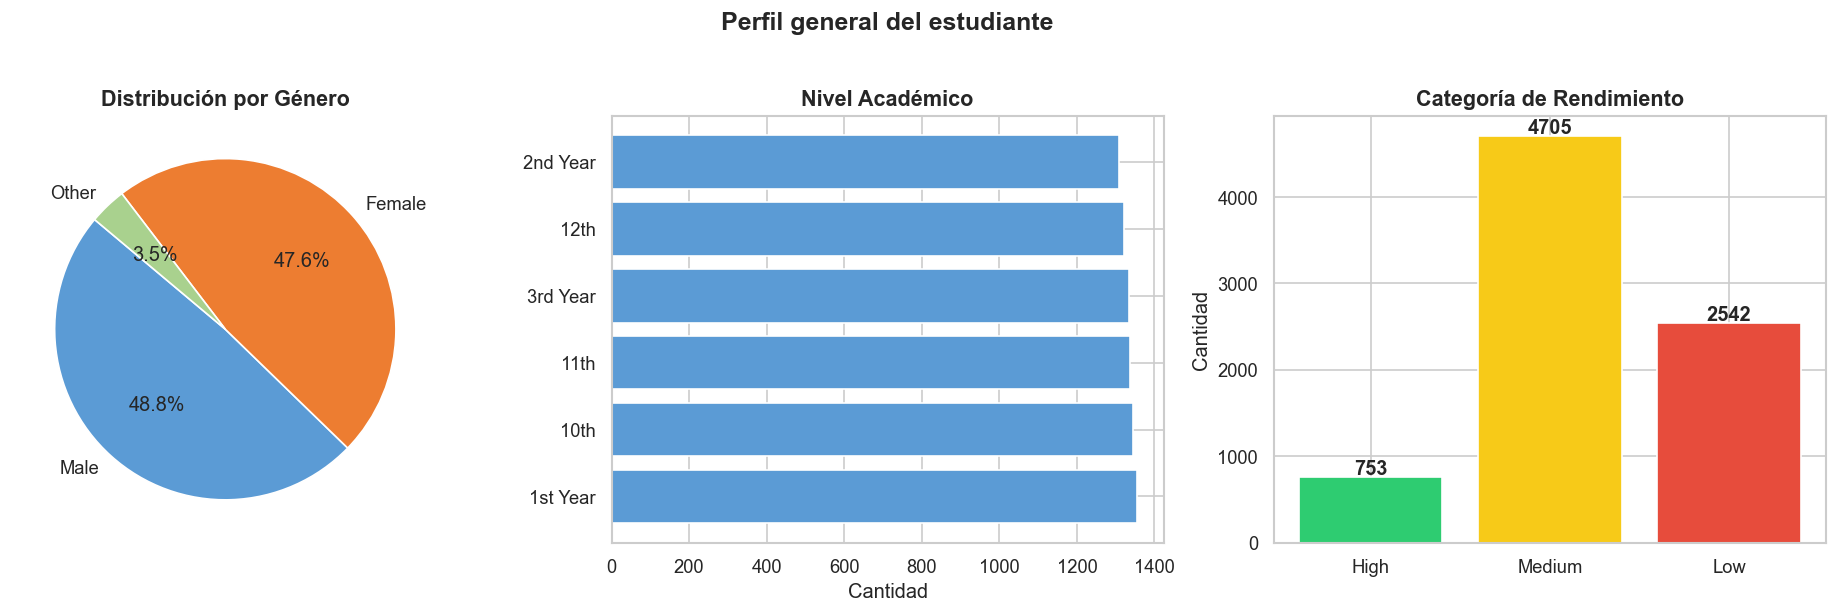

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Género
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#5b9bd5','#ed7d31','#a9d18e'], startangle=140)
axes[0].set_title('Distribución por Género')

# Nivel académico
grade_counts = df['grade_level'].value_counts()
axes[1].barh(grade_counts.index, grade_counts.values,
             color='#5b9bd5', edgecolor='white')
axes[1].set_title('Nivel Académico')
axes[1].set_xlabel('Cantidad')

# Rendimiento
perf_counts = df['performance_category'].value_counts().reindex(['High','Medium','Low'])
axes[2].bar(perf_counts.index, perf_counts.values,
            color=['#2ecc71','#f7ca18','#e74c3c'], edgecolor='white')
axes[2].set_title('Categoría de Rendimiento')
axes[2].set_ylabel('Cantidad')
for i, v in enumerate(perf_counts.values):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Perfil general del estudiante', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig("graficos_informe/ds02_plot_5.png", bbox_inches="tight", dpi=150)


---
## 4. Uso de la IA — ¿Quién la usa y cómo?

In [6]:
# % que usa IA
usa_ia = df['uses_ai'].value_counts(normalize=True) * 100
print(f"Usan IA: {usa_ia.get(1, 0):.1f}%")
print(f"No usan IA: {usa_ia.get(0, 0):.1f}%")

Usan IA: 64.1%
No usan IA: 35.9%


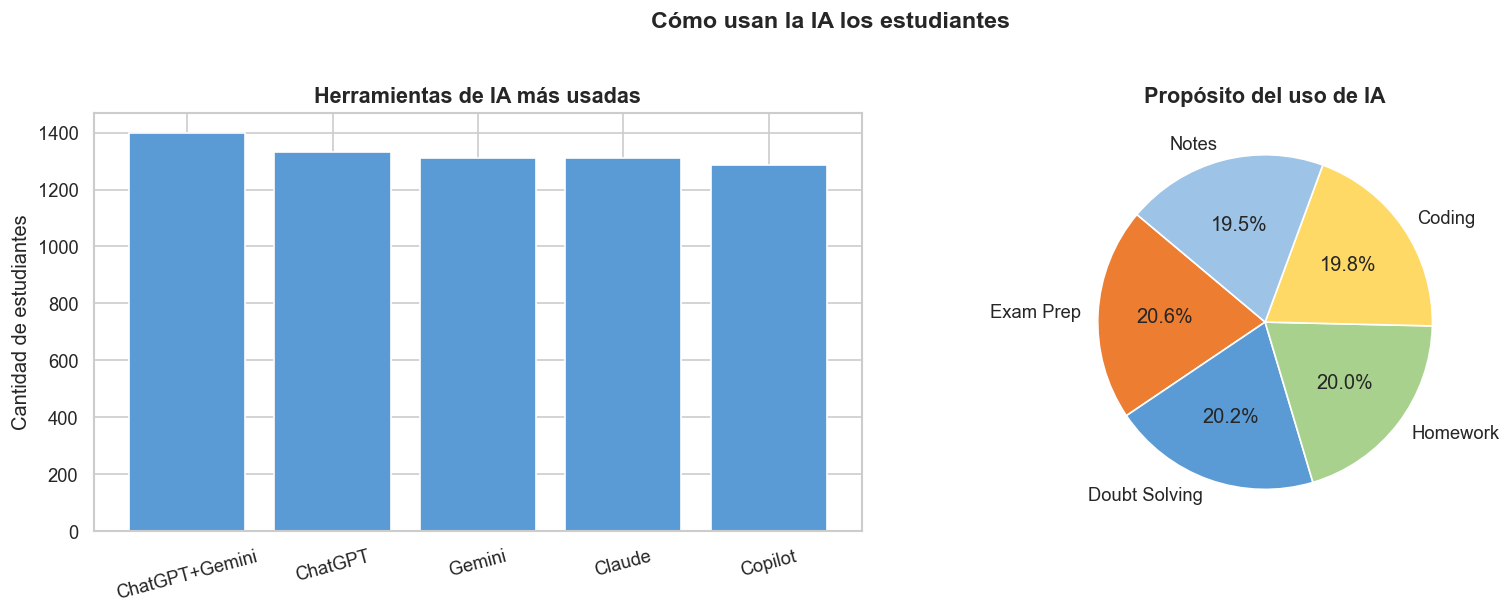

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Herramientas más usadas
tools = df['ai_tools_used'].value_counts().dropna()
axes[0].bar(tools.index, tools.values, color='#5b9bd5', edgecolor='white')
axes[0].set_title('Herramientas de IA más usadas')
axes[0].set_ylabel('Cantidad de estudiantes')
axes[0].tick_params(axis='x', rotation=15)

# Propósito de uso
purpose = df['ai_usage_purpose'].value_counts().dropna()
colors_p = ['#ed7d31','#5b9bd5','#a9d18e','#ffd966','#9dc3e6']
axes[1].pie(purpose, labels=purpose.index, autopct='%1.1f%%',
            colors=colors_p, startangle=140)
axes[1].set_title('Propósito del uso de IA')

plt.suptitle('Cómo usan la IA los estudiantes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig("graficos_informe/ds02_plot_8.png", bbox_inches="tight", dpi=150)


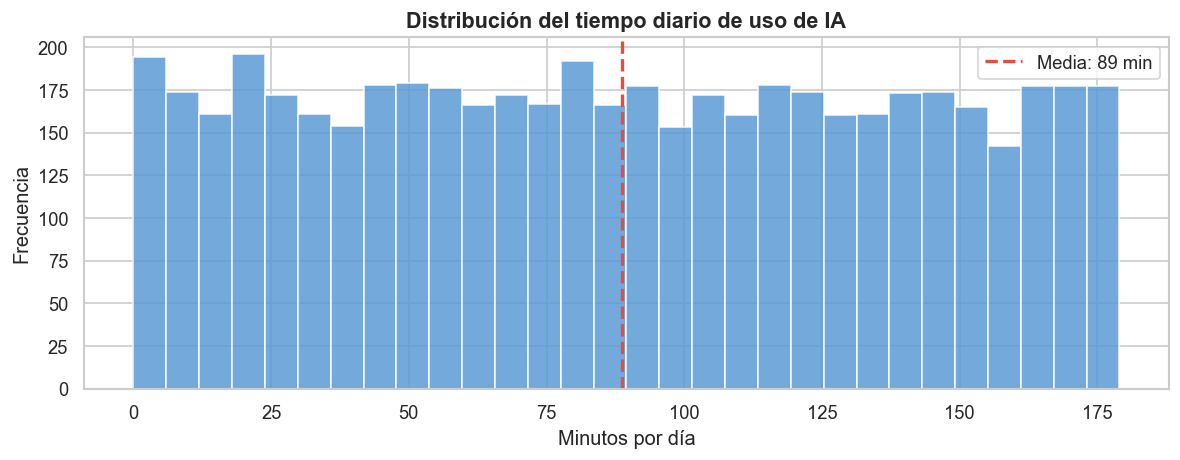

In [13]:
# Distribución del tiempo de uso de IA (minutos por día)
ai_users = df[df['uses_ai'] == 1]

plt.figure(figsize=(10, 4))
plt.hist(ai_users['ai_usage_time_minutes'], bins=30,
         color='#5b9bd5', edgecolor='white', alpha=0.85)
plt.axvline(ai_users['ai_usage_time_minutes'].mean(), color='#e74c3c',
            linestyle='--', linewidth=2,
            label=f"Media: {ai_users['ai_usage_time_minutes'].mean():.0f} min")
plt.title('Distribución del tiempo diario de uso de IA')
plt.xlabel('Minutos por día')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Impacto de la IA en el rendimiento académico

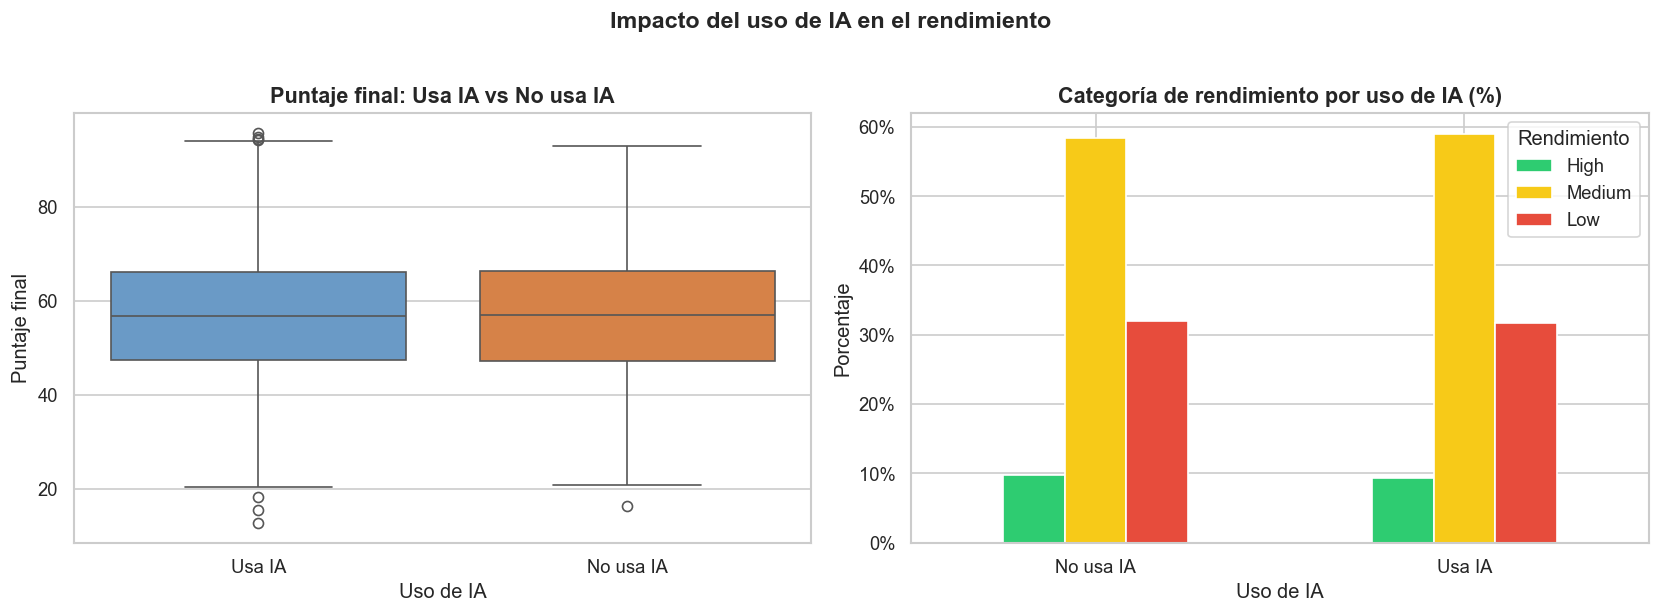

In [14]:
# Comparación de puntaje final: usuarios IA vs no usuarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df['Uso de IA'] = df['uses_ai'].map({1: 'Usa IA', 0: 'No usa IA'})
sns.boxplot(data=df, x='Uso de IA', y='final_score',
            palette={'Usa IA': '#5b9bd5', 'No usa IA': '#ed7d31'},
            ax=axes[0])
axes[0].set_title('Puntaje final: Usa IA vs No usa IA')
axes[0].set_ylabel('Puntaje final')

# Rendimiento por categoría de uso de IA
perf_ia = df.groupby(['Uso de IA', 'performance_category']).size().unstack(fill_value=0)
perf_ia_pct = perf_ia.div(perf_ia.sum(axis=1), axis=0) * 100
perf_ia_pct[['High','Medium','Low']].plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#f7ca18','#e74c3c'],
    edgecolor='white')
axes[1].set_title('Categoría de rendimiento por uso de IA (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Rendimiento')

plt.suptitle('Impacto del uso de IA en el rendimiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig("graficos_informe/ds02_plot_11.png", bbox_inches="tight", dpi=150)


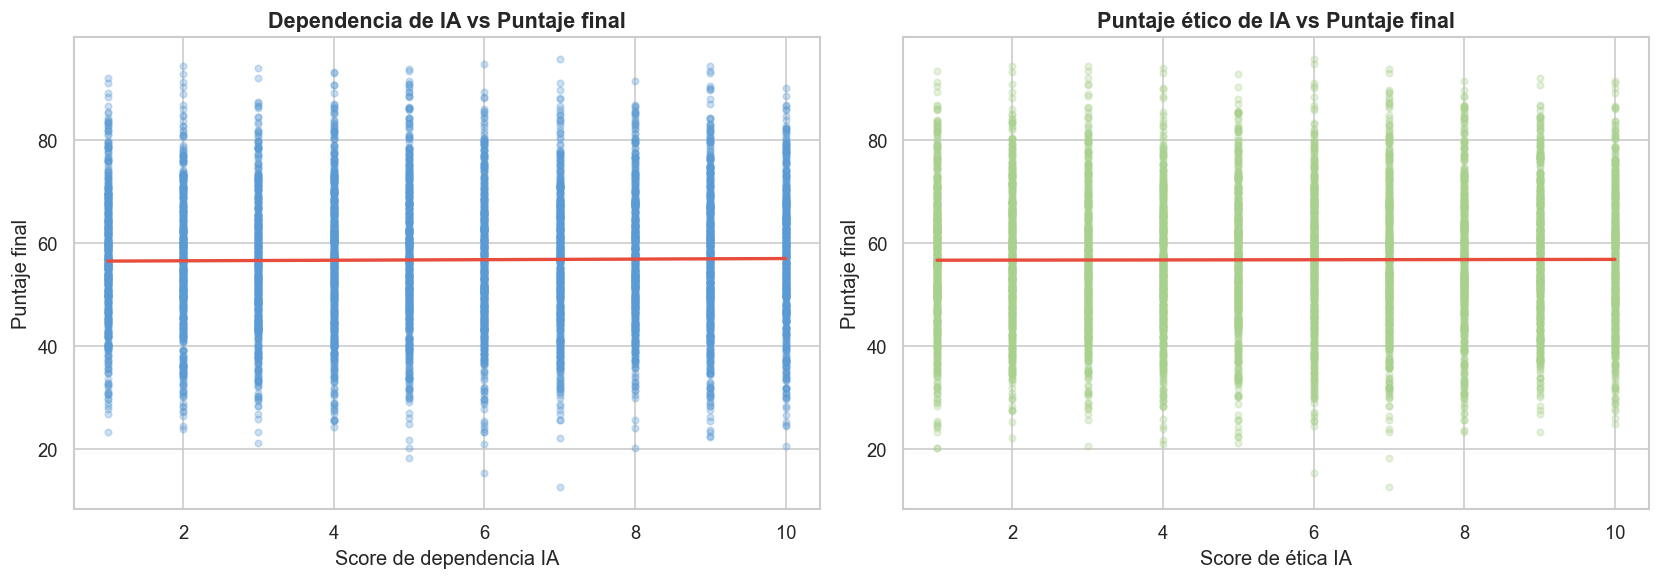

In [15]:
# Correlación: dependencia de IA vs puntaje final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ai_users = df[df['uses_ai'] == 1]

# Dependencia vs puntaje
axes[0].scatter(ai_users['ai_dependency_score'], ai_users['final_score'],
                alpha=0.3, color='#5b9bd5', s=15)
m, b = np.polyfit(ai_users['ai_dependency_score'], ai_users['final_score'], 1)
x_line = np.linspace(ai_users['ai_dependency_score'].min(), ai_users['ai_dependency_score'].max())
axes[0].plot(x_line, m*x_line + b, color='#e74c3c', linewidth=2)
axes[0].set_title('Dependencia de IA vs Puntaje final')
axes[0].set_xlabel('Score de dependencia IA')
axes[0].set_ylabel('Puntaje final')

# Ética de IA vs puntaje
axes[1].scatter(ai_users['ai_ethics_score'], ai_users['final_score'],
                alpha=0.3, color='#a9d18e', s=15)
m2, b2 = np.polyfit(ai_users['ai_ethics_score'], ai_users['final_score'], 1)
x_line2 = np.linspace(ai_users['ai_ethics_score'].min(), ai_users['ai_ethics_score'].max())
axes[1].plot(x_line2, m2*x_line2 + b2, color='#e74c3c', linewidth=2)
axes[1].set_title('Puntaje ético de IA vs Puntaje final')
axes[1].set_xlabel('Score de ética IA')
axes[1].set_ylabel('Puntaje final')

plt.tight_layout()
plt.show()
plt.savefig("graficos_informe/ds02_plot_12.png", bbox_inches="tight", dpi=150)


---
## 6. Hábitos del estudiante — Sueño, estudio y redes sociales

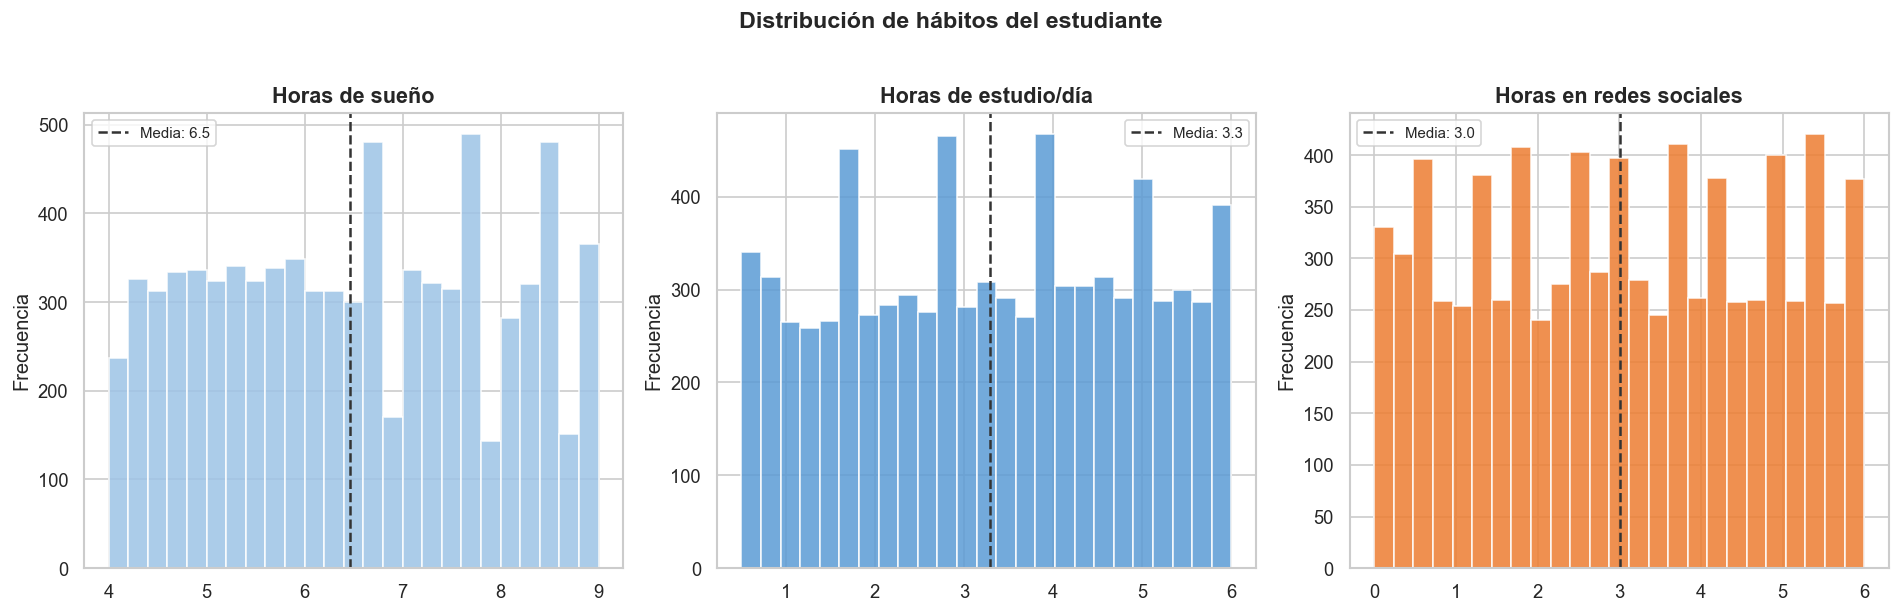

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
habit_cols = ['sleep_hours', 'study_hours_per_day', 'social_media_hours']
habit_labels = ['Horas de sueño', 'Horas de estudio/día', 'Horas en redes sociales']
habit_colors = ['#9dc3e6', '#5b9bd5', '#ed7d31']

for ax, col, label, color in zip(axes, habit_cols, habit_labels, habit_colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='#333', linestyle='--', linewidth=1.5,
               label=f'Media: {df[col].mean():.1f}')
    ax.set_title(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de hábitos del estudiante', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig("graficos_informe/ds02_plot_14.png", bbox_inches="tight", dpi=150)


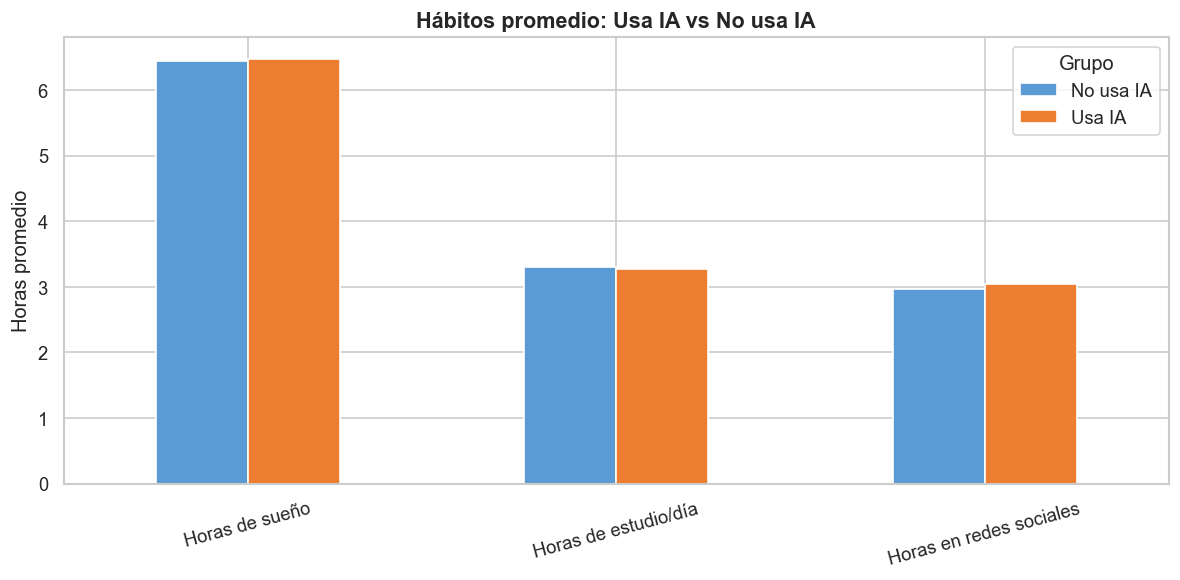

In [16]:
# Comparación de hábitos: usa IA vs no usa IA
habit_compare = df.groupby('Uso de IA')[habit_cols].mean().T
habit_compare.index = habit_labels
habit_compare.plot(kind='bar', figsize=(10, 5),
                   color=['#5b9bd5','#ed7d31'], edgecolor='white')
plt.title('Hábitos promedio: Usa IA vs No usa IA', fontweight='bold')
plt.ylabel('Horas promedio')
plt.xticks(rotation=15)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

---
## 7. Mapa de correlaciones

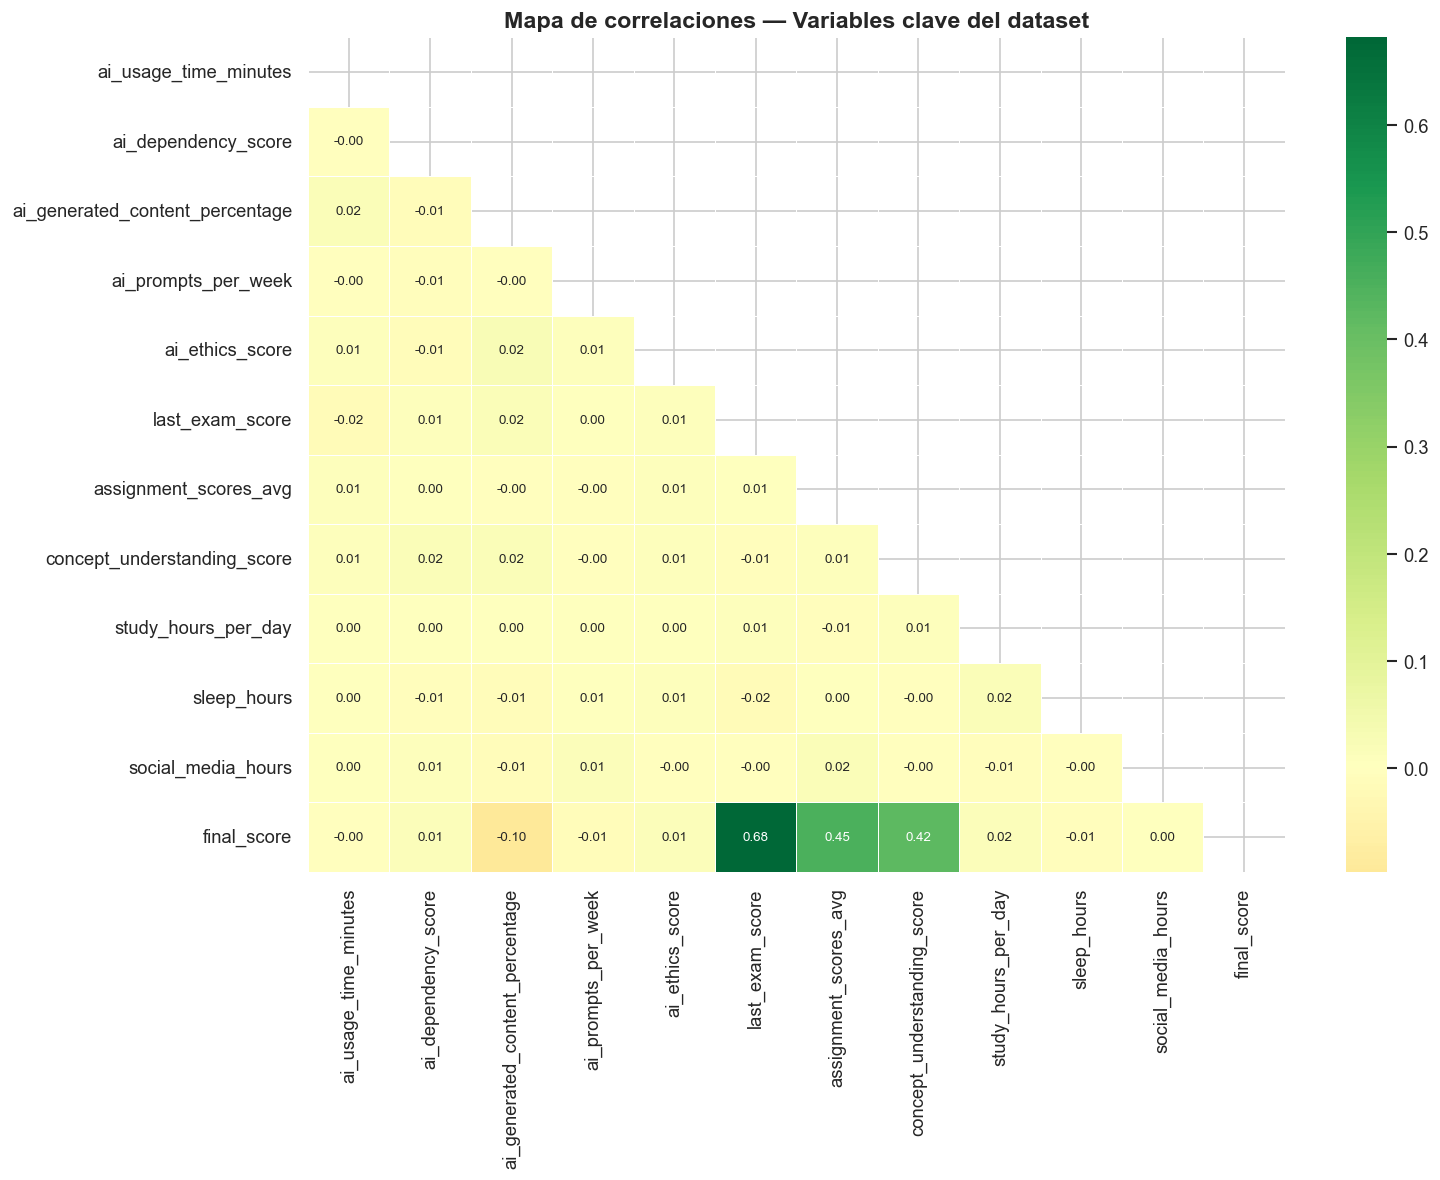

In [17]:
corr_cols = [
    'ai_usage_time_minutes', 'ai_dependency_score',
    'ai_generated_content_percentage', 'ai_prompts_per_week',
    'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg',
    'concept_understanding_score', 'study_hours_per_day',
    'sleep_hours', 'social_media_hours', 'final_score'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Mapa de correlaciones — Variables clave del dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig("graficos_informe/ds02_plot_17.png", bbox_inches="tight", dpi=150)


---
## 8. Tabla resumen por rendimiento académico

In [18]:
summary = df.groupby('performance_category').agg(
    n_estudiantes=('student_id', 'count'),
    pct_usa_ia=('uses_ai', lambda x: f"{x.mean()*100:.1f}%"),
    tiempo_ia_min=('ai_usage_time_minutes', 'mean'),
    dependencia_ia=('ai_dependency_score', 'mean'),
    etica_ia=('ai_ethics_score', 'mean'),
    horas_estudio=('study_hours_per_day', 'mean'),
    horas_sueno=('sleep_hours', 'mean'),
    redes_sociales=('social_media_hours', 'mean'),
    puntaje_final=('final_score', 'mean')
).round(2).reindex(['High','Medium','Low'])

print('=== Resumen por categoría de rendimiento ===')
summary

=== Resumen por categoría de rendimiento ===


,n_estudiantes,pct_usa_ia,tiempo_ia_min,dependencia_ia,etica_ia,horas_estudio,horas_sueno,redes_sociales,puntaje_final
performance_category,,,,,,,,,
High,753,63.1%,88.60,5.69,5.56,3.38,6.39,3.03,80.70
Medium,4705,64.4%,89.05,5.48,5.50,3.29,6.47,3.01,61.24
Low,2542,63.9%,88.99,5.52,5.39,3.26,6.47,3.01,41.54
